# Implementación, refinamiento y evaluación de modelos

## Detección de voz real vs. voz sintética

Este notebook corresponde a la etapa final del proyecto. Aquí se entrenan modelos de clasificación utilizando las características acústicas generadas previamente y se evalúa su rendimiento con métricas como **accuracy, precision, recall, F1-score** y **curva ROC**.

El objetivo es determinar qué tan bien el modelo puede diferenciar entre audios reales y audios sintéticos.

## 1. Librerías

In [44]:
import os
import zipfile
from glob import glob

import numpy as np
pandas_installed = True
try:
    import pandas as pd
except ImportError:
    pandas_installed = False
    raise

import matplotlib.pyplot as plt

import librosa

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42

## 2. Definición de rutas

Se usan los conjuntos de **training**, **validation** y **testing**. Si tu carpeta tiene otro nombre, solo cambia la variable `BASE_PATH`.

In [45]:
BASE_PATH = '../dataset/for-norm/for-norm'

for candidate in for_norm_candidates:
    if (os.path.isdir(os.path.join(candidate, 'training')) and
        os.path.isdir(os.path.join(candidate, 'validation')) and
        os.path.isdir(os.path.join(candidate, 'testing'))):
        BASE_PATH = candidate
        break

if BASE_PATH is None:
    # Ajusta manualmente si fuera necesario
    BASE_PATH = '../dataset/for-norm/for-norm'

print('BASE_PATH:', BASE_PATH)

TRAIN_REAL = os.path.join(BASE_PATH, 'training', 'real', '*.wav')
TRAIN_FAKE = os.path.join(BASE_PATH, 'training', 'fake', '*.wav')
VAL_REAL = os.path.join(BASE_PATH, 'validation', 'real', '*.wav')
VAL_FAKE = os.path.join(BASE_PATH, 'validation', 'fake', '*.wav')
TEST_REAL = os.path.join(BASE_PATH, 'testing', 'real', '*.wav')
TEST_FAKE = os.path.join(BASE_PATH, 'testing', 'fake', '*.wav')

train_real_files = glob(TRAIN_REAL)
train_fake_files = glob(TRAIN_FAKE)
val_real_files = glob(VAL_REAL)
val_fake_files = glob(VAL_FAKE)
test_real_files = glob(TEST_REAL)
test_fake_files = glob(TEST_FAKE)

print('Train real:', len(train_real_files))
print('Train fake:', len(train_fake_files))
print('Validation real:', len(val_real_files))
print('Validation fake:', len(val_fake_files))
print('Test real:', len(test_real_files))
print('Test fake:', len(test_fake_files))

BASE_PATH: ../dataset/for-norm/for-norm
Train real: 26941
Train fake: 26927
Validation real: 5400
Validation fake: 5398
Test real: 2264
Test fake: 2370


## 3. Extracción de características

Se reutiliza el enfoque del notebook anterior: MFCC, ZCR, centroide espectral, ancho de banda espectral, rolloff y energía RMS.

Para evitar tiempos de ejecución muy largos, se usa `LIMIT_PER_CLASS`. Puedes subirlo si tu computadora lo soporta.

In [46]:
def extract_features(file_path, n_mfcc=13):
    audio, sr = librosa.load(file_path, sr=None)

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    zcr = librosa.feature.zero_crossing_rate(audio)
    spectral_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=sr)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr)
    rms = librosa.feature.rms(y=audio)

    features = {
        'duration': len(audio) / sr,
        'sample_rate': sr,
        'zcr_mean': float(np.mean(zcr)),
        'zcr_std': float(np.std(zcr)),
        'spectral_centroid_mean': float(np.mean(spectral_centroid)),
        'spectral_centroid_std': float(np.std(spectral_centroid)),
        'spectral_bandwidth_mean': float(np.mean(spectral_bandwidth)),
        'spectral_bandwidth_std': float(np.std(spectral_bandwidth)),
        'spectral_rolloff_mean': float(np.mean(spectral_rolloff)),
        'spectral_rolloff_std': float(np.std(spectral_rolloff)),
        'rms_mean': float(np.mean(rms)),
        'rms_std': float(np.std(rms)),
    }

    for i in range(n_mfcc):
        features[f'mfcc_{i+1}_mean'] = float(np.mean(mfcc[i]))
        features[f'mfcc_{i+1}_std'] = float(np.std(mfcc[i]))

    return features


def build_feature_table(real_files, fake_files, limit_per_class=None):
    rows = []

    if limit_per_class is not None:
        real_files = real_files[:limit_per_class]
        fake_files = fake_files[:limit_per_class]

    for f in real_files:
        try:
            features = extract_features(f)
            features['label'] = 0
            features['class_name'] = 'real'
            features['file_name'] = os.path.basename(f)
            rows.append(features)
        except Exception as e:
            print(f'Error en archivo real {f}: {e}')

    for f in fake_files:
        try:
            features = extract_features(f)
            features['label'] = 1
            features['class_name'] = 'fake'
            features['file_name'] = os.path.basename(f)
            rows.append(features)
        except Exception as e:
            print(f'Error en archivo fake {f}: {e}')

    return pd.DataFrame(rows)

## 4. Construcción de tablas de entrenamiento, validación y prueba

In [47]:
LIMIT_PER_CLASS = 500

# Si ya existen los CSV, se cargan para ahorrar tiempo. Si no existen, se generan.
if all(os.path.exists(f) for f in ['features_train.csv', 'features_val.csv', 'features_test.csv']):
    df_train = pd.read_csv('features_train.csv')
    df_val = pd.read_csv('features_val.csv')
    df_test = pd.read_csv('features_test.csv')
    print('Características cargadas desde CSV.')
else:
    df_train = build_feature_table(train_real_files, train_fake_files, limit_per_class=LIMIT_PER_CLASS)
    df_val = build_feature_table(val_real_files, val_fake_files, limit_per_class=LIMIT_PER_CLASS)
    df_test = build_feature_table(test_real_files, test_fake_files, limit_per_class=LIMIT_PER_CLASS)

    df_train.to_csv('features_train.csv', index=False)
    df_val.to_csv('features_val.csv', index=False)
    df_test.to_csv('features_test.csv', index=False)
    print('Características generadas y guardadas en CSV.')

print('Train:', df_train.shape)
print('Validation:', df_val.shape)
print('Test:', df_test.shape)

df_train.head()

Características cargadas desde CSV.
Train: (1000, 41)
Validation: (1000, 41)
Test: (1000, 41)


,duration,sample_rate,zcr_mean,zcr_std,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_rolloff_mean,spectral_rolloff_std,...,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,label,class_name,file_name
0,2.501625,16000,0.137460,0.107712,1822.402563,1013.998924,1500.086348,461.650089,3311.115506,1478.543864,...,11.559100,-13.836758,12.222466,-7.984338,11.914497,3.527972,9.191851,0,real,file1.wav_16k.wav_norm.wav_mono.wav_silence.wav
1,3.903625,16000,0.154065,0.142022,1768.520360,1094.012772,1465.244396,334.323075,3338.242828,1384.581857,...,11.825932,-8.748560,11.612570,-3.333729,7.162339,0.747619,8.394314,0,real,file10.wav_16k.wav_norm.wav_mono.wav_silence.wav
2,3.491062,16000,0.095206,0.108298,1446.031905,1158.978658,1533.366622,512.955487,2730.610795,2073.645401,...,9.080853,-5.557889,10.118580,-1.045880,11.342929,-8.296654,9.514001,0,real,file100.wav_16k.wav_norm.wav_mono.wav_silence.wav
3,9.532187,16000,0.188090,0.168110,2033.304687,1437.124038,1511.028950,553.590827,3504.194631,2048.101107,...,14.186908,-23.158998,12.469375,-6.387084,10.967032,-4.906898,9.316609,0,real,file1000.wav_16k.wav_norm.wav_mono.wav_silence...
4,4.185125,16000,0.193106,0.200250,2081.626495,1636.240108,1411.119670,539.384866,3395.873092,2131.512957,...,12.260044,-18.606726,13.310192,-13.368902,9.351854,0.640401,9.405801,0,real,file10000.wav_16k.wav_norm.wav_mono.wav_silenc...


## 6. Separación de variables predictoras y etiquetas

In [48]:
excluded_columns = ['label', 'class_name', 'file_name']
feature_columns = [col for col in df_train.columns if col not in excluded_columns]

X_train = df_train[feature_columns]
y_train = df_train['label']

X_val = df_val[feature_columns]
y_val = df_val['label']

X_test = df_test[feature_columns]
y_test = df_test['label']

print('Cantidad de características:', len(feature_columns))
print('X_train:', X_train.shape)
print('X_val:', X_val.shape)
print('X_test:', X_test.shape)

Cantidad de características: 38
X_train: (1000, 38)
X_val: (1000, 38)
X_test: (1000, 38)


## 7. Modelo base: Regresión Logística

Se utiliza como modelo inicial porque es simple, rápido y sirve como punto de comparación para modelos más complejos.

In [49]:
log_reg_model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

log_reg_model.fit(X_train, y_train)

y_val_pred_lr = log_reg_model.predict(X_val)
y_val_proba_lr = log_reg_model.predict_proba(X_val)[:, 1]

print('Resultados en validación - Regresión Logística')
print(classification_report(y_val, y_val_pred_lr, target_names=['real', 'fake']))

Resultados en validación - Regresión Logística
              precision    recall  f1-score   support

        real       0.93      0.93      0.93       500
        fake       0.93      0.93      0.93       500

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



## 8. Modelo principal: Random Forest

Random Forest es adecuado para este proyecto porque trabaja bien con características tabulares, no requiere supuestos lineales fuertes y permite capturar relaciones no lineales entre las variables acústicas.

In [50]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_val_pred_rf = rf_model.predict(X_val)
y_val_proba_rf = rf_model.predict_proba(X_val)[:, 1]

print('Resultados en validación - Random Forest inicial')
print(classification_report(y_val, y_val_pred_rf, target_names=['real', 'fake']))

Resultados en validación - Random Forest inicial
              precision    recall  f1-score   support

        real       0.94      0.92      0.93       500
        fake       0.92      0.94      0.93       500

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



## 9. Refinamiento del modelo Random Forest

Se aplica una búsqueda de hiperparámetros para mejorar el rendimiento del modelo. El criterio principal será el **F1-score**, ya que combina precision y recall.

In [51]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_rf_model = grid_search.best_estimator_

print('Mejores hiperparámetros:')
print(grid_search.best_params_)
print('Mejor F1 promedio en validación cruzada:', grid_search.best_score_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Mejores hiperparámetros:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mejor F1 promedio en validación cruzada: 0.9402617504751941


## 10. Evaluación en conjunto de prueba

Después de seleccionar el mejor modelo, se evalúa con el conjunto de prueba. Este conjunto no se utiliza para entrenar ni para ajustar hiperparámetros, por lo que permite estimar mejor el rendimiento final.

In [52]:
models = {
    'Regresión Logística': log_reg_model,
    'Random Forest inicial': rf_model,
    'Random Forest refinado': best_rf_model
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        'modelo': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).sort_values(by='f1_score', ascending=False)
results_df

,modelo,accuracy,precision,recall,f1_score,roc_auc
0,Regresión Logística,0.734,0.673077,0.910,0.773810,0.814080
1,Random Forest inicial,0.721,0.665667,0.888,0.760925,0.784146
2,Random Forest refinado,0.721,0.667171,0.882,0.759690,0.775028


## 11. Reporte detallado del mejor modelo

In [53]:
best_model_name = results_df.iloc[0]['modelo']
best_model = models[best_model_name]

y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

print('Mejor modelo:', best_model_name)
print('Reporte de clasificación:')
print(classification_report(y_test, y_test_pred, target_names=['real', 'fake']))

Mejor modelo: Regresión Logística
Reporte de clasificación:
              precision    recall  f1-score   support

        real       0.86      0.56      0.68       500
        fake       0.67      0.91      0.77       500

    accuracy                           0.73      1000
   macro avg       0.77      0.73      0.73      1000
weighted avg       0.77      0.73      0.73      1000



## 12. Matriz de confusión

La matriz de confusión permite observar cuántos audios reales y sintéticos fueron clasificados correctamente o incorrectamente.

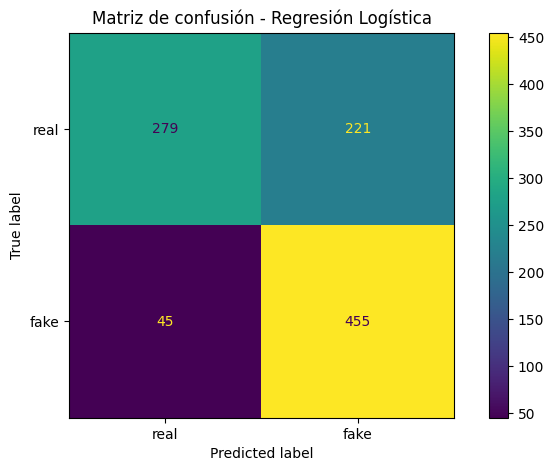

In [54]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['real', 'fake'])
disp.plot()
plt.title(f'Matriz de confusión - {best_model_name}')
plt.show()

## 13. Curva ROC

La curva ROC evalúa la capacidad del modelo para separar ambas clases usando distintos umbrales de decisión. Un AUC cercano a 1 indica mejor separación entre audios reales y sintéticos.

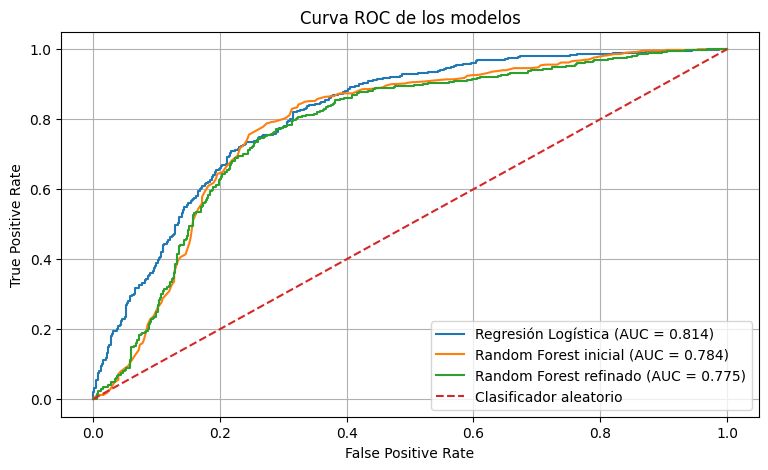

In [55]:
plt.figure()

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', label='Clasificador aleatorio')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC de los modelos')
plt.legend()
plt.grid(True)
plt.show()

## 14. Importancia de características

En Random Forest se puede revisar qué variables aportaron más a la clasificación. Esto ayuda a interpretar el modelo y conectar los resultados con el problema.

In [56]:
# Para extraer importancia, usamos el mejor Random Forest refinado.
importances = pd.DataFrame({
    'feature': feature_columns,
    'importance': best_rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

importances.head(15)

,feature,importance
0,duration,0.248809
10,rms_mean,0.093481
36,mfcc_13_mean,0.058989
37,mfcc_13_std,0.045733
25,mfcc_7_std,0.035465
19,mfcc_4_std,0.033590
13,mfcc_1_std,0.032686
30,mfcc_10_mean,0.029281
12,mfcc_1_mean,0.026805
22,mfcc_6_mean,0.023901


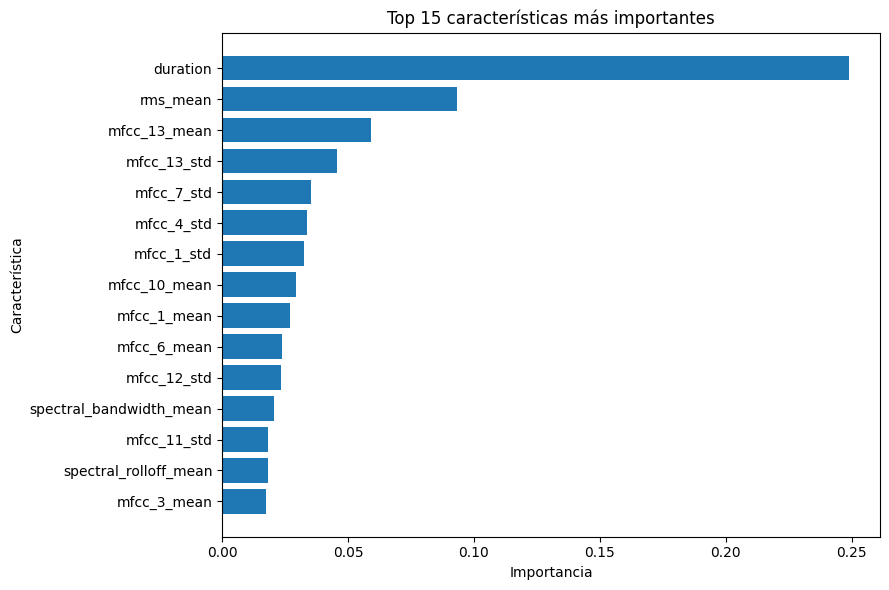

In [57]:
top_features = importances.head(15)

plt.figure(figsize=(9, 6))
plt.barh(top_features['feature'][::-1], top_features['importance'][::-1])
plt.title('Top 15 características más importantes')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

## 15. Interpretación de resultados

En esta etapa se compararon distintos modelos para clasificar audios como **reales** o **sintéticos**. La regresión logística funcionó como modelo base, mientras que Random Forest se utilizó como modelo principal porque puede capturar relaciones no lineales entre las características acústicas extraídas.

Las métricas principales utilizadas fueron accuracy, precision, recall y F1-score. En el contexto del problema, el **recall** es importante porque indica qué tantos audios sintéticos fueron detectados correctamente. Esto es relevante porque un audio sintético clasificado erróneamente como real podría representar un riesgo en escenarios de verificación de identidad o análisis forense. Por otro lado, la **precision** indica qué tan confiables son las predicciones cuando el modelo etiqueta un audio como sintético.

El **F1-score** permite evaluar el equilibrio entre precision y recall, por lo que resulta útil cuando se desea un modelo que no solo detecte muchos casos sintéticos, sino que también mantenga una cantidad controlada de falsos positivos. Además, la curva ROC y el valor AUC permiten analizar la capacidad general del modelo para separar ambas clases.

En general, si el modelo Random Forest refinado obtiene mejores valores de F1-score y AUC que el modelo base, se puede concluir que las características acústicas seleccionadas sí aportan información útil para distinguir entre voz real y voz sintética. Sin embargo, el rendimiento final también depende del tamaño de muestra utilizado, la calidad de los audios y la capacidad computacional disponible para procesar el dataset completo.

## 16. Conclusiones

1. Se implementaron modelos de clasificación para distinguir entre audios reales y sintéticos utilizando características acústicas extraídas previamente.

2. Random Forest permitió obtener un modelo más flexible que la regresión logística, ya que puede capturar relaciones no lineales entre variables como MFCC, energía RMS y características espectrales.

3. Las métricas de evaluación permiten analizar el desempeño desde distintas perspectivas. En este problema, el F1-score y el AUC son especialmente útiles porque resumen la capacidad del modelo para clasificar correctamente ambas clases.

4. La curva ROC permite observar la separación entre clases y comparar visualmente el desempeño de los modelos. Un AUC alto indicaría que el modelo tiene buena capacidad para distinguir entre audios reales y sintéticos.

5. Como mejora futura, se podría entrenar una CNN usando espectrogramas Mel para comparar un enfoque de Deep Learning con el modelo basado en características acústicas.